In [5]:
# Importing Library
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

<Axes: xlabel='skill_count', ylabel='skill_pay'>

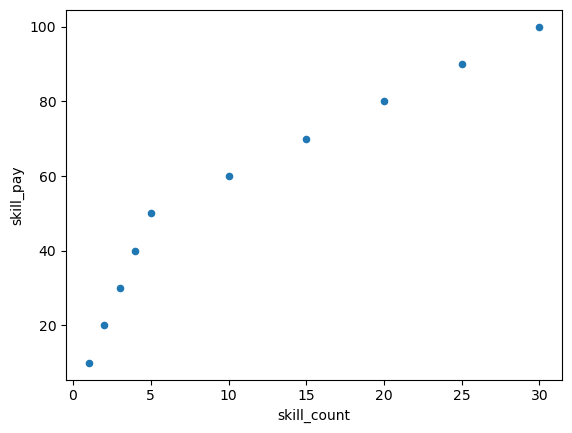

In [6]:
data = {
    'job_skills': ['Python','Sql', 'Java', 'c++', 'c#', 'javascript', 'html', 'css', 'php', 'ruby'],
    'skill_count' : [30, 25, 20, 15, 10, 5, 4, 3, 2, 1],
    'skill_pay' : [100,90,80,70,60,50,40,30,20,10]
}

df = pd.DataFrame(data)

df.plot(kind='scatter', x='skill_count', y='skill_pay')

In [7]:
#df =df[df['job_title_short'] == 'Data Analyst']

In [8]:
df = df[df['job_title_short'] == 'Data Analyst']
import ast

df['job_skills'] = df['job_skills'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else x
)

# 	isinstance(x, str) → only convert strings ✅
#	•	If already list → leave it as it is ✅

KeyError: 'job_title_short'

In [9]:
df_exploded = df.explode('job_skills')

skill_stats = df_exploded.groupby('job_skills').agg(
    skill_count=('job_skills', 'count'),
    median_salary=('salary_year_avg', 'median')
)

skills_stats = skill_stats.sort_values(by='skill_count', ascending = False).head(10)
skills_stats.index

KeyError: "Label(s) ['salary_year_avg'] do not exist"

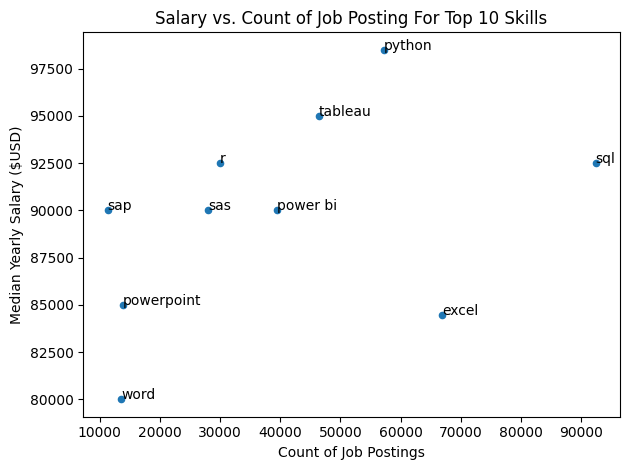

In [ ]:
skills_stats.plot(kind='scatter', x='skill_count', y='median_salary')
plt.xlabel('Count of Job Postings')
plt.ylabel('Median Yearly Salary ($USD)')
plt.title('Salary vs. Count of Job Posting For Top 10 Skills')

for i,txt in enumerate(skills_stats.index):
    plt.text(skills_stats['skill_count'].iloc[i], skills_stats['median_salary'].iloc[i], txt)

plt.tight_layout()
plt.show()

In [10]:
df.columns

Index(['job_skills', 'skill_count', 'skill_pay'], dtype='str')